In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

# Nuevas librerías para la conexión a la base de datos y variables de entorno
import os
from dotenv import load_dotenv
from sqlalchemy import create_engine, exc

In [3]:
# df_stable = pd.read_csv("../data/clean/datos_preprocesados_clean.csv")

In [4]:
try:
    # 1. Cargar las variables de entorno desde el archivo .env
    load_dotenv(dotenv_path="../.env") 
    
    db_user = os.getenv("DB_USER")
    db_pass = os.getenv("DB_PASS")
    db_host = os.getenv("DB_HOST")
    db_name = os.getenv("DB_NAME")
    
    # Validar que existan todas las credenciales requeridas
    if not all([db_user, db_pass, db_host, db_name]):
        raise ValueError("Faltan una o más variables de entorno en el archivo .env")

    # 2. Crear el motor de conexión (engine)
    connection_string = f"mysql+pymysql://{db_user}:{db_pass}@{db_host}/{db_name}"
    engine = create_engine(connection_string)
    
    # 3. Consulta SQL uniendo histórico y la tabla maestra de Stablecoins
    # Mantenemos h.stablecoin_id por si acaso y renombramos el nombre de la moneda a 'stablecoin'
    query = """
    SELECT 
        h.stablecoin_id,
        s.nombre_stablecoin AS stablecoin,
        h.datetime,
        h.price,
        h.market_cap,
        h.peg_deviation,
        h.supply_change_1d,
        h.supply_change_7d,
        h.price_volatility_3d
    FROM Preprocesados_Historico h
    INNER JOIN Stablecoins s ON h.stablecoin_id = s.stablecoin_id;
    """
    
    # 4. Cargar los datos directamente en el DataFrame original del notebook
    df_stable = pd.read_sql(query, con=engine)
    print(f"¡Conexión exitosa! Se han cargado {len(df_stable)} registros bivariados de Stablecoins.")

except ValueError as ve:
    print(f"Error de Configuración: {ve}")
except exc.SQLAlchemyError as se:
    print(f"Error de Base de Datos: No se pudo conectar o extraer el histórico de stablecoins.\nDetalles: {se}")
except Exception as e:
    print(f"Error Inesperado: {e}")

¡Conexión exitosa! Se han cargado 814367 registros bivariados de Stablecoins.


### Correlación de características

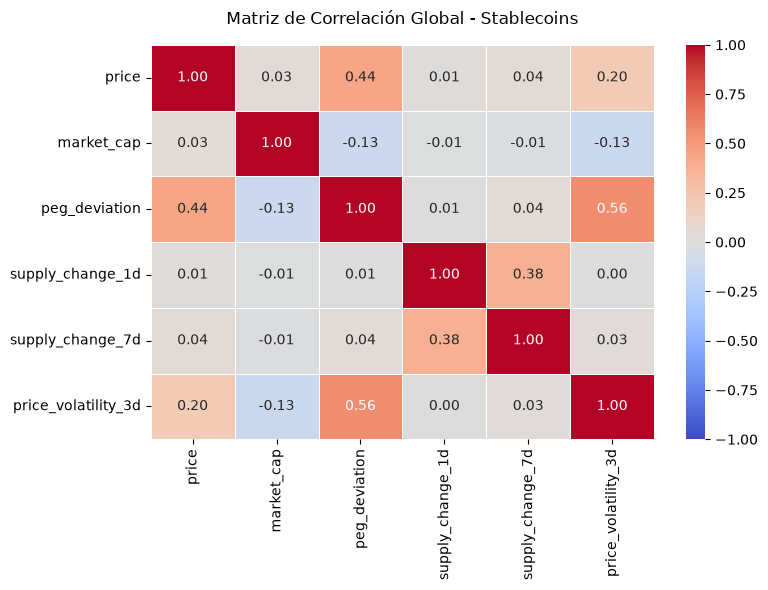

In [5]:
# 1. Panorama General: Heatmap de Correlación

plt.figure(figsize=(8, 6))
# Filtramos solo numéricas
num_cols_stable = ['price', 'market_cap', 'peg_deviation', 'supply_change_1d', 'supply_change_7d', 'price_volatility_3d']
sns.heatmap(df_stable[num_cols_stable].corr(), annot=True, cmap='coolwarm', fmt=".2f", linewidths=0.5, vmin=-1, vmax=1)
plt.title('Matriz de Correlación Global - Stablecoins', fontsize=12, pad=15)
plt.tight_layout()
plt.show()

- Cuando la volatilidad del precio a 3 días sube, la desviación del peg tiende a aumentar de forma notable.

    Utilidad para el modelo: Esto le confirma a tu algoritmo que la       volatilidad a corto plazo y la pérdida de paridad caminan de la mano. Juntas van a aislar de forma muy eficiente las anomalías.
- A mayor capitalización de mercado, menor volatilidad y menor desviación del peg. Las monedas grandes (USDT, USDC) se mueven menos que las pequeñas (PYUSD, USDE).

#### Distribución de Variables

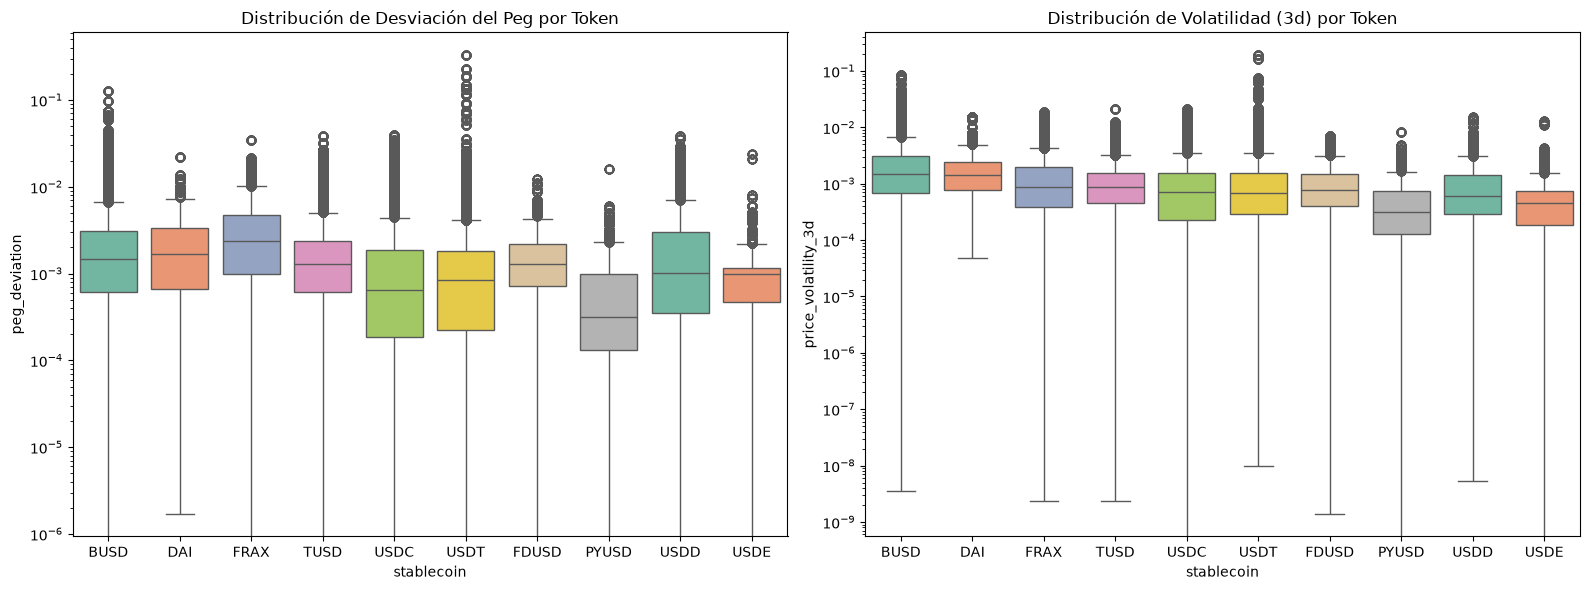

In [6]:
# 2. Categórica vs Numérica: Boxplots por Stablecoin
# =========================================================================
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

# Boxplot Peg Deviation (Escala logarítmica opcional si USDD/FRAX deforman el gráfico)
sns.boxplot(data=df_stable, x='stablecoin', y='peg_deviation', ax=axes[0], palette='Set2', hue='stablecoin')
axes[0].set_title('Distribución de Desviación del Peg por Token')
axes[0].set_yscale('log') # Usamos escala logarítmica porque las desviaciones suelen ser milimétricas excepto en crisis

# Boxplot Volatilidad a 3 días
sns.boxplot(data=df_stable, x='stablecoin', y='price_volatility_3d', ax=axes[1], palette='Set2', hue='stablecoin')
axes[1].set_title('Distribución de Volatilidad (3d) por Token')
axes[1].set_yscale('log')

plt.tight_layout()
plt.show()

##### Distribución de Desviación de Peg
- Los gigantes estables (USDC y USDT): Mira las cajas verde (USDC) y amarilla (USDT). Sus cajas están situadas notablemente más abajo que las demás (alrededor de $10^{-3}$ o menos). Esto significa que en su día a día normal, sus desviaciones son minúsculas (milésimas de centavo).

- Aunque la caja de USDT está muy abajo, sus outliers (los puntos negros superiores) llegan casi a $10^{0}$ (cerca de 10-20 centavos de desviación). Es la que tiene la cola de anomalías más alta y agresiva del gráfico.

##### Distribución de Volatilidad a 3 dias 
- BUSD (Verde azulado): Tiene la caja más alta en volatilidad. Esto tiene todo el sentido histórico si el dataset cubre la época en la que Binance y Paxos dejaron de emitirla y el mercado empezó a arbitrar y retirar fondos en masa. Su "normalidad" se volvió muy volátil.

- La rigidez de USDC y USDT: Vuelven a mostrar las cajas más bajas y compactas, lo que confirma que el precio de estos dos gigantes suele quedarse "congelado" o moviéndose en rangos muy estrechos durante la mayor parte del tiempo.


#### Relación de Volatidiad y Desviación del Peg

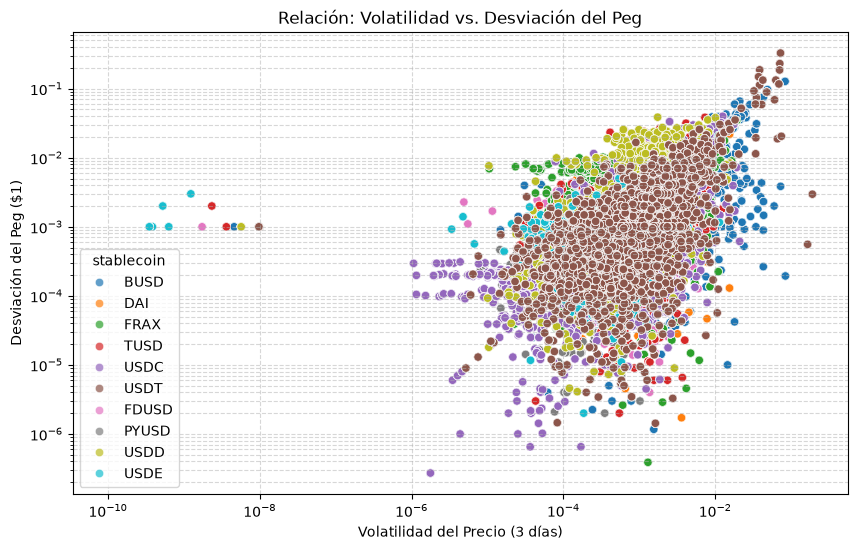

In [7]:
# =========================================================================
# 3. Numérica vs Numérica: Scatter Plot Clave
# =========================================================================
plt.figure(figsize=(10, 6))
sns.scatterplot(data=df_stable, x='price_volatility_3d', y='peg_deviation', hue='stablecoin', alpha=0.7)
plt.title('Relación: Volatilidad vs. Desviación del Peg')
plt.xlabel('Volatilidad del Precio (3 días)')
plt.ylabel('Desviación del Peg ($1)')
plt.xscale('log')
plt.yscale('log')
plt.grid(True, which="both", ls="--", alpha=0.5)
plt.show()

- El denso cúmulo entre $10^{-4}$ y $10^{-2}$ en volatilidad, y por debajo de $10^{-2}$ en desviación, representa el comportamiento normal del mercado, concetración de la Stablecoin mas estable USDT.

- A mayor volatilidad de 3 días, mayor desviación del peg. Lo interesante es que el "frente" de esta cola está dominado masivamente por USDT (celeste) en los extremos más altos (llegando a desviaciones cercanas a $10^{-1}$, es decir, 10 centavos de dólar).

- Los flotantes a la izquierda del gráfico, pertenecen principalmente a USDE (amarillo verdoso), TUSD (marrón) y FDUSD (verde). Esto ocurre cuando una moneda cotiza exactamente a un precio fijo desviado (por ejemplo, $1.001 o $0.999) de forma perfectamente lineal y plana durante 3 días (volatilidad 0).

### Evolución de Desviacion del Peg

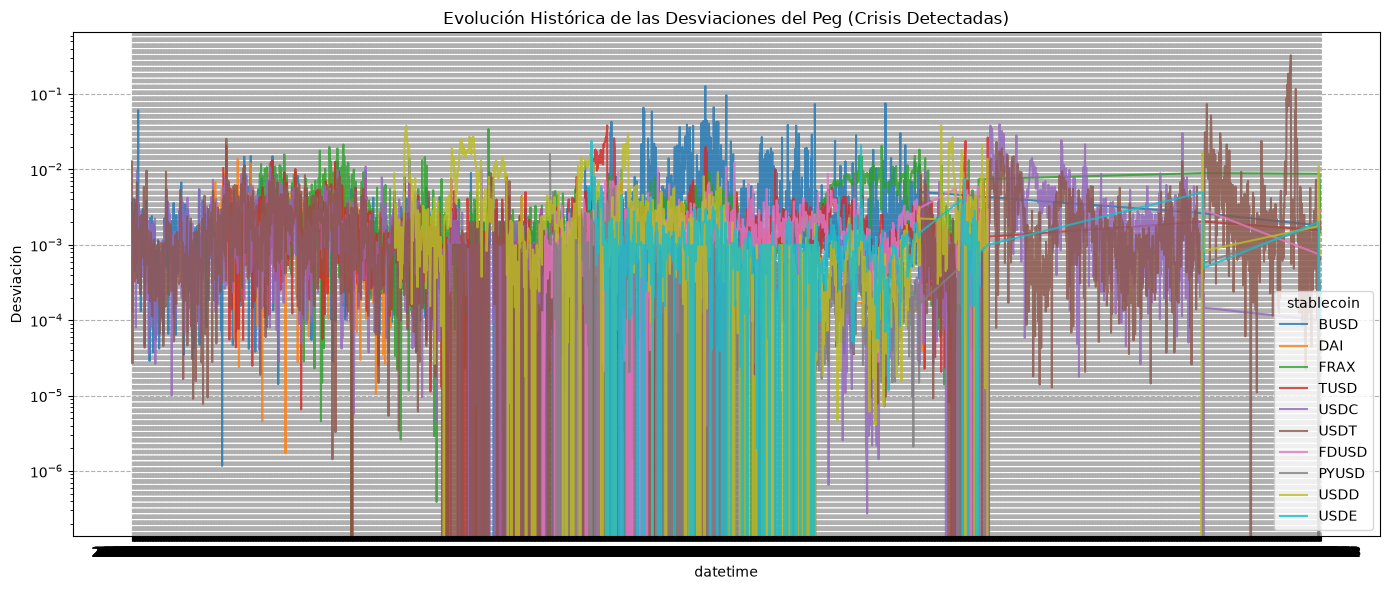

In [8]:
# =========================================================================
# 4. Evolución Temporal Bivariada
# =========================================================================
plt.figure(figsize=(14, 6))
sns.lineplot(data=df_stable, x='datetime', y='peg_deviation', hue='stablecoin', alpha=0.8)
plt.title('Evolución Histórica de las Desviaciones del Peg (Crisis Detectadas)')
plt.ylabel('Desviación')
plt.yscale('log')
plt.grid(True, ls='--')
plt.tight_layout()
plt.show()

En este gráfico analizamos la salud histórica de las principales stablecoins. Al usar una escala logarítmica en el eje Y, podemos ver con mucha sensibilidad incluso las micro-desviaciones. Los picos más altos que ven en pantalla son las radiografías exactas de las mayores crisis de confianza del sector, donde el peg se rompió temporalmente.

Picos de Crisis (Eventos de Depeg): Los picos más altos (especialmente los que superan el nivel de $10^{-2}$ o llegan a $10^{-1}$) marcan los momentos exactos en los que monedas específicas sufrieron crisis severas de confianza o liquidez perdiendo su paridad de 1:1.

#### Relación de Volatidiad y Desviación del Peg

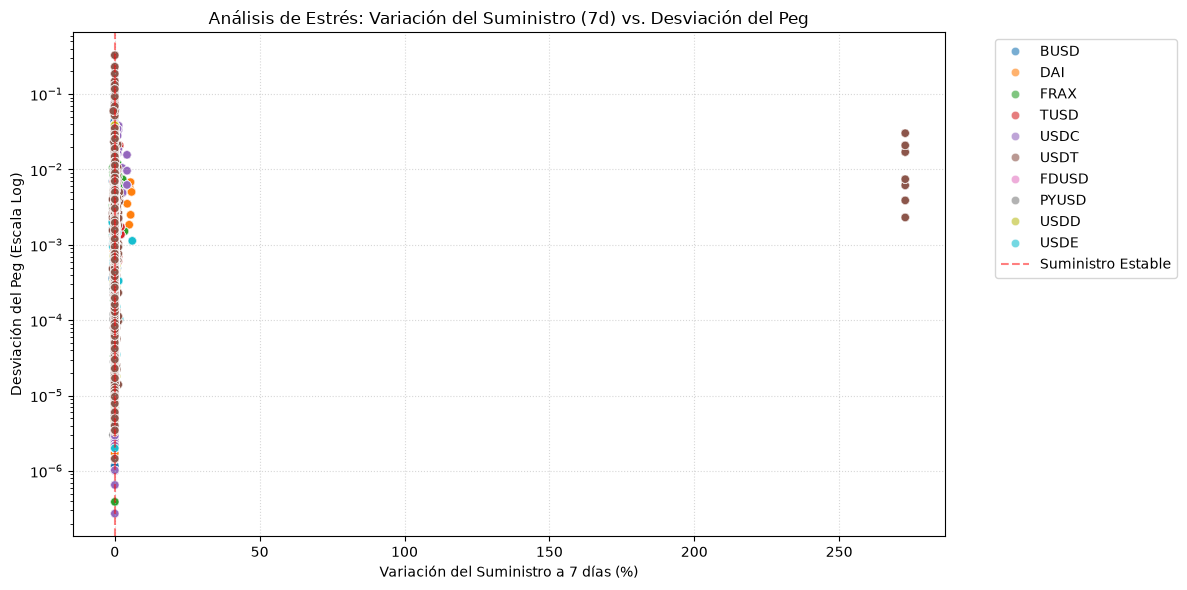

In [11]:
plt.figure(figsize=(12, 6))

# Cruzamos la variación de suministro a 7 días con la desviación del peg
sns.scatterplot(
    data=df_stable, 
    x='supply_change_7d', 
    y='peg_deviation', 
    hue='stablecoin', 
    alpha=0.6,
    palette='tab10'
)

# Línea vertical en 0: todo lo que esté a la izquierda es reducción de suministro (fuga de dinero)
plt.axvline(0, color='red', linestyle='--', alpha=0.5, label='Suministro Estable')

plt.yscale('log') # Escala logarítmica crucial para ver los depegs
plt.title('Análisis de Estrés: Variación del Suministro (7d) vs. Desviación del Peg')
plt.xlabel('Variación del Suministro a 7 días (%)')
plt.ylabel('Desviación del Peg (Escala Log)')
plt.grid(True, ls=':', alpha=0.5)
plt.legend(bbox_to_anchor=(1.05, 1), loc='upper left')
plt.tight_layout()
plt.show()

- Esto demuestra que en el 99% de los días ordinarios, el suministro apenas cambia (0%), pero el precio sí tiene micro-desviaciones de centavos (sube hacia 0.05 o 0.10 de desviación absoluta). Para el Isolation Forest, todo lo que esté en esa "columna central" baja va a ser muy fácil de catalogar como Clase 1 (normal).

- Lo puntos azules de USDT que se disparan hacia arriba, tocando desviaciones del 0.20, 0.25 y más de 0.30 (es decir, el precio cayó a $0.70 o $0.80 en momentos críticos de su historia).

- Lo puntos aislados en el extremo derecho, cerca del 275% de variación del suministro, para USDT vemos que esa moneda multiplicó su suministro casi por tres en solo una semana. Es un comportamiento radicalmente anómalo que el Isolation Forest va a cazar al vuelo como Clase -1.